In [1]:
import pandas as pd
import numpy as np
from typing import Tuple

from sklearn.metrics import mean_squared_error

import pymc as pm
import xarray as xr
import arviz as az
import arviz_plots as azp

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.text as mtext

RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.5
numpy: 2.4.3
pymc: 6.2.0
pytensor: 3.2.4
arviz: 1.3.0
arviz_plots: 1.3.0


In [2]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs)-> xr.DataTree:
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        xr.DataTree.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling

    Returns:
        xr.DataTree: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [3]:
# first use handy index function
def define_index(data: pd.DataFrame, label: str) -> Tuple[np.array, dict]:
    """Defines an index variable starting at 0.
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values.astype("int32")
    return index_vals, lookup

def map_index(data: pd.DataFrame, label: str, lookup_dict: dict) -> np.array:
    """Applies an index to new values
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format
        lookup_dict (dict): dictionary that contains the mappings from inputs to index

    Returns:
        np.array: indexed values
    """
    s = data[label].astype(str)
    vals = s.map(lookup_dict).values
    return vals

In [4]:
# import data
df = pd.read_csv('data/bat_speed_model_data_monthly.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,bips,ev90,latent_ev90_mean,latent_ev90_std,swing_total,bat_speed,imputed_bat_speed,model_bat_speed,is_imputed,is_complete
0,120074,2016,Mar/Apr,0,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,62.0,107.51,106.912555,0.668270,168.0,NaN,73.480547,73.480547,1,0
1,120074,2016,May,1,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,78.0,108.94,106.957928,0.629956,193.0,NaN,73.520621,73.520621,1,0
2,120074,2016,Jun,2,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,73.0,105.84,106.910381,0.625869,176.0,NaN,73.481695,73.481695,1,0
3,120074,2016,Jul,3,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,76.0,106.45,106.905053,0.629203,181.0,NaN,73.476159,73.476159,1,0
4,120074,2016,Aug,4,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,79.0,107.94,106.924604,0.655354,180.0,NaN,73.492950,73.492950,1,0


In [5]:
# standardize age
age_mean = np.mean(df['age'])
age_std = np.std(df['age'])
df['age_z'] = (df['age'] - age_mean)/age_std

# define age and age squared for the model
age_values = df['age_z'].values
age_sq_values = age_values**2

n_obs = len(df)
df["player_idx"], player_lookup = define_index(df, "player_full_id")
player_idx_vals = df['player_idx'].values.astype("int32")
player_name_list = list(player_lookup.keys())
is_imputed_data_vals = df['is_imputed'].values.astype("int32")

bat_speed_target = df['model_bat_speed'].values
swings_sqrt_values = np.sqrt(df['swing_total'].values)

# define emprical prior for bat speed
prior_mean = np.mean(bat_speed_target)
prior_std = np.std(bat_speed_target)
print(prior_mean)
print(prior_std)


70.01904913604103
2.6782324938280113


In [100]:
df['age'].describe()

count    28997.000000
mean        28.573757
std          3.681784
min         19.553730
25%         25.828884
50%         28.104038
75%         31.008898
max         44.561259
Name: age, dtype: float64

<Axes: >

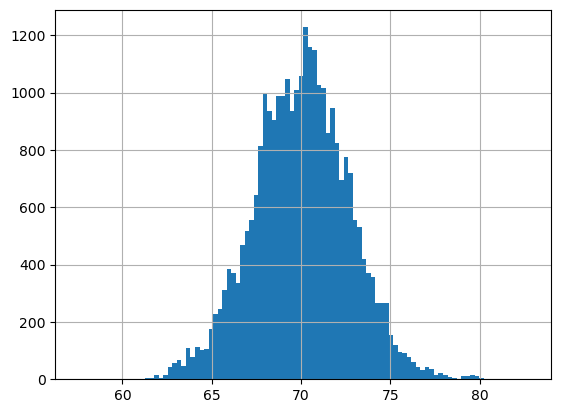

In [6]:
df['model_bat_speed'].hist(bins=100)

In [7]:
print(prior_mean+prior_std*1.25*3)
print(prior_mean-prior_std*1.25*3)

assert(np.isnan(swings_sqrt_values).sum() == 0)

80.06242098789608
59.97567728418599


In [8]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
}   

# pymc model
with pm.Model(coords=coords) as model_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_values, dims=("observation_id",))
    age_sq_data = pm.Data('age_sq_data', age_sq_values, dims=("observation_id",))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # player random
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop, sigma=sigma_player, dims=("player",))
    
    # age
    a = pm.Normal("a", mu=0, sigma=1)
    b = pm.Normal("b", mu=0, sigma=1)
    f = pm.Deterministic('f', a*age_sq_data + b*age_data)

    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [9]:
trace_quad = sample(model_quad, draws = 2000, tune = 4000, target_accept = 0.99,  path='quad_model.nc')

NUTS[nutpie]: [mu_pop, sigma_player, mu_player, a, b, sigma_imputed, sigma_observed]


Output()

In [10]:
az.summary(trace_quad, var_names=['mu_pop', 'sigma_player', 'a', 'b', 'sigma_imputed', 'sigma_observed'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_pop,69.65,0.06,69.53,69.78,13194.69,6404.64,1.0,0.0,0.0
sigma_player,2.53,0.05,2.44,2.62,13064.83,6415.59,1.0,0.0,0.0
a,-0.13,0.00,-0.14,-0.12,2045.65,3176.73,1.0,0.0,0.0
b,0.03,0.01,0.02,0.04,1911.47,2746.48,1.0,0.0,0.0
sigma_imputed,4.88,0.03,4.83,4.93,10857.13,6625.36,1.0,0.0,0.0
sigma_observed,14.22,0.11,14.00,14.44,11006.42,6613.35,1.0,0.0,0.0


In [11]:
az.summary(trace_quad, var_names=['mu_player'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[David Ortiz (120074)],74.77,0.16,74.46,75.07,8181.27,5610.40,1.0,0.00,0.00
mu_player[Alex Rodriguez (121347)],73.01,0.24,72.53,73.47,12214.36,5776.58,1.0,0.00,0.00
mu_player[Adrian Beltré (134181)],70.29,0.10,70.10,70.48,8512.28,5220.30,1.0,0.00,0.00
mu_player[Carlos Beltrán (136860)],71.33,0.12,71.10,71.56,7774.98,5884.60,1.0,0.00,0.00
mu_player[Jayson Werth (150029)],72.28,0.13,72.03,72.53,11646.38,5668.79,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...
mu_player[Brett Callahan (814430)],71.01,1.98,67.21,74.90,14736.34,6289.58,1.0,0.02,0.01
mu_player[Ryan Waldschmidt (814439)],71.57,0.71,70.17,72.98,13024.67,6037.40,1.0,0.01,0.00
mu_player[Sean Keys (815873)],73.14,1.33,70.52,75.69,15949.59,6078.11,1.0,0.01,0.01
mu_player[Sung-Mun Song (823550)],71.14,0.89,69.40,72.87,14951.20,6303.93,1.0,0.01,0.00


In [12]:
def plot_aging_curve(trace, age_z, model_name="Model"):
    f_draws = trace.posterior["f"].values
    curves = f_draws.reshape(-1, f_draws.shape[-1])

    sort_idx = np.argsort(age_z)
    age_sorted = age_z[sort_idx]
    curves_sorted = curves[:, sort_idx]

    _, ax = plt.subplots(figsize=(8, 6))
    rng = np.random.default_rng(RANDOM_SEED)
    subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
    for idx in subset_indices:
        ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

    ax.set_title(f"{model_name} Aging Curve")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Bat Speed Change (mph)")
    ax.set_ylim(-3, 1)
    ax.grid(True)
    plt.show()
    return curves_sorted

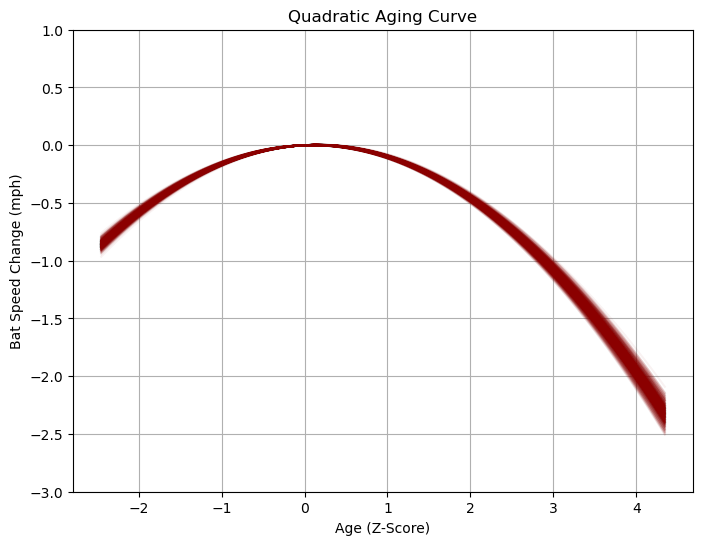

In [13]:
quad_aging_curve = plot_aging_curve(trace_quad, age_values, model_name="Quadratic")

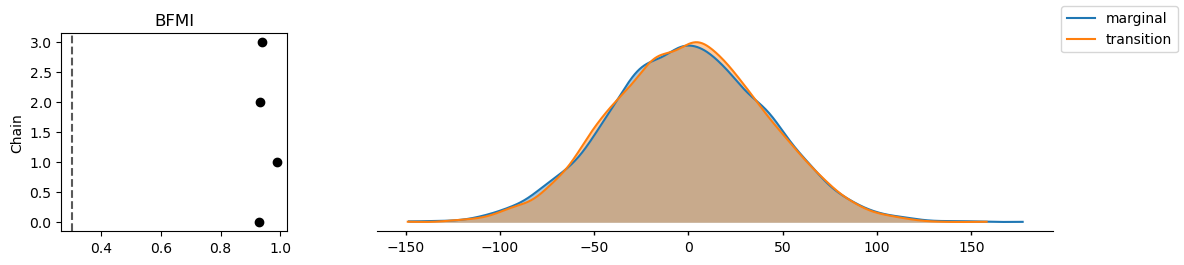

In [14]:
az.plot_energy(trace_quad)

In [15]:
spp = sample_posterior_pred(model_quad, trace_quad)

Sampling: [target]


Output()

Text(0.5, 0, 'Bat Speed (mph)')

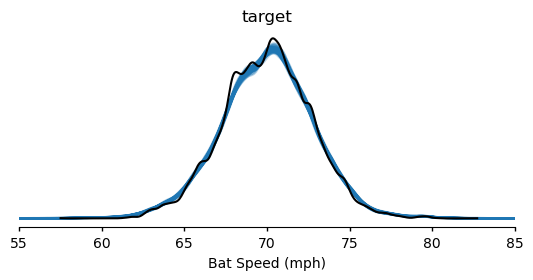

In [16]:
pc = azp.plot_ppc_dist(spp, var_names="target", num_samples=100)
ax = pc.viz["plot"]["target"].item()
ax.set_xlim(55, 85)
ax.set_xlabel("Bat Speed (mph)")

In [17]:
a_posterior_mean = trace_quad.posterior['a'].mean(dim=("chain", "draw")).values.flatten()
b_posterior_mean = trace_quad.posterior['b'].mean(dim=("chain", "draw")).values.flatten()
a_posterior_std = trace_quad.posterior['a'].std(dim=("chain", "draw")).values.flatten()
b_posterior_std = trace_quad.posterior['b'].std(dim=("chain", "draw")).values.flatten()

In [18]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_values), np.max(age_values)],
    lengthscale_range=[0.75, 1.25],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 9, c: 1.20


In [19]:
class QuadraticMean(pm.gp.mean.Mean):
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def __call__(self, X):
        x = X[:, 0]
        return self.a * x**2 + self.b * x

In [20]:
# add position
pdf = df[['bam_id','player_full_id','full','position','position_hybrid']].drop_duplicates(['player_full_id']).reset_index(drop=True)
pdf["position_idx"], position_lookup = define_index(pdf, "position")
position_idx_vals = pdf['position_idx'].values.astype("int32")
position_name_list = list(position_lookup.keys())
pdf.head()

,bam_id,player_full_id,full,position,position_hybrid,position_idx
0,120074,David Ortiz (120074),David Ortiz,DH,DH,0
1,121347,Alex Rodriguez (121347),Alex Rodriguez,SS,UTM,1
2,134181,Adrian Beltré (134181),Adrian Beltré,3B,CINF,2
3,136860,Carlos Beltrán (136860),Carlos Beltrán,CF,UTM,3
4,150029,Jayson Werth (150029),Jayson Werth,RF,COF,4


In [21]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "position": position_name_list
}

with pm.Model(coords=coords) as model_gp_position:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data("age_data", age_values.reshape(-1, 1))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    position_idx = pm.Data('position_idx', position_idx_vals, dims=('player',))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # position
    sigma_position = pm.HalfNormal("sigma_position", 1.0)
    position_effect = pm.ZeroSumNormal("position_effect", sigma=sigma_position, dims="position")
    # player
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop + position_effect[position_idx], sigma=sigma_player, dims=("player",))
    
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    mean = QuadraticMean(a, b)
    # covariance priors
    eta = pm.HalfNormal("eta", 0.25)
    ls = pm.InverseGamma("ls", alpha=15, beta=14)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    # HSGP
    gp_position = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp_position.prior("f", X=age_data)
    
    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [22]:
trace_gp_position = sample(model_gp_position, draws = 2000, tune = 4000, target_accept = 0.99,  path='gp_expquad_quadratic_position.nc')

NUTS[nutpie]: [mu_pop, sigma_position, position_effect, sigma_player, mu_player, a, b, eta, ls, f_hsgp_coeffs, sigma_imputed, sigma_observed]


Output()

In [23]:
az.summary(trace_gp_position, var_names=['eta','ls','mu_pop','sigma_player','a','b','sigma_imputed','sigma_observed',
                                         'sigma_position','position_effect'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta,0.23,0.08,0.12,0.42,487.73,798.90,1.00,0.00,0.00
ls,0.70,0.11,0.51,0.92,811.94,1037.22,1.00,0.00,0.00
mu_pop,69.80,0.07,69.66,69.95,1544.90,2829.47,1.00,0.00,0.00
sigma_player,2.34,0.04,2.26,2.43,8222.15,6373.59,1.00,0.00,0.00
a[0],-0.13,0.00,-0.14,-0.12,446.30,914.74,1.01,0.00,0.00
b[0],0.03,0.01,0.02,0.05,2148.68,3344.97,1.00,0.00,0.00
sigma_imputed,4.86,0.03,4.81,4.91,7973.39,6400.14,1.00,0.00,0.00
sigma_observed,14.24,0.11,14.03,14.46,7807.48,6356.96,1.00,0.00,0.00
sigma_position,1.17,0.28,0.75,1.84,8644.42,6214.35,1.00,0.00,0.00
position_effect[DH],2.09,0.28,1.53,2.64,8735.25,6712.47,1.00,0.00,0.00


In [24]:
player_effects = az.summary(trace_gp_position, var_names=['mu_player'], ci_prob=0.95, round_to=2)
player_effects = player_effects.reset_index(drop=False)
player_effects['player_full_id'] = player_effects['index'].str.extract(r'\[(.*?)\]')
player_effects.tail(10)

,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,player_full_id
1699,mu_player[Hyeseong Kim (808975)],66.38,0.60,65.19,67.53,10692.28,6323.92,1.0,0.01,0.00,Hyeseong Kim (808975)
1700,mu_player[Jung Hoo Lee (808982)],67.74,0.31,67.13,68.35,10149.44,6154.88,1.0,0.00,0.00,Jung Hoo Lee (808982)
1701,mu_player[Ben Williamson (810938)],68.67,0.45,67.80,69.56,10173.48,6349.85,1.0,0.00,0.00,Ben Williamson (810938)
1702,mu_player[Joshua Kuroda-Grauer (811965)],68.26,1.13,66.05,70.48,10264.29,6470.42,1.0,0.01,0.01,Joshua Kuroda-Grauer (811965)
1703,mu_player[Jonah Cox (813841)],68.66,1.28,66.15,71.16,11137.87,6410.96,1.0,0.01,0.01,Jonah Cox (813841)
1704,mu_player[Brett Callahan (814430)],71.04,1.87,67.42,74.75,11047.62,6262.50,1.0,0.02,0.01,Brett Callahan (814430)
1705,mu_player[Ryan Waldschmidt (814439)],71.48,0.72,70.08,72.91,10898.33,6381.46,1.0,0.01,0.00,Ryan Waldschmidt (814439)
1706,mu_player[Sean Keys (815873)],73.66,1.28,71.12,76.17,10076.46,6335.47,1.0,0.01,0.01,Sean Keys (815873)
1707,mu_player[Sung-Mun Song (823550)],70.90,0.91,69.09,72.69,10475.03,6207.01,1.0,0.01,0.01,Sung-Mun Song (823550)
1708,mu_player[Lucas Spence (828599)],71.33,1.38,68.63,74.07,10336.58,5844.42,1.0,0.01,0.01,Lucas Spence (828599)


In [25]:
player_effects.head(10)

,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,player_full_id
0,mu_player[David Ortiz (120074)],74.88,0.16,74.58,75.19,4835.29,6081.88,1.0,0.00,0.0,David Ortiz (120074)
1,mu_player[Alex Rodriguez (121347)],73.12,0.23,72.67,73.58,6992.51,5977.17,1.0,0.00,0.0,Alex Rodriguez (121347)
2,mu_player[Adrian Beltré (134181)],70.17,0.10,69.99,70.37,6016.29,5835.70,1.0,0.00,0.0,Adrian Beltré (134181)
3,mu_player[Carlos Beltrán (136860)],71.35,0.12,71.11,71.59,4559.66,5003.53,1.0,0.00,0.0,Carlos Beltrán (136860)
4,mu_player[Jayson Werth (150029)],72.11,0.13,71.86,72.36,7935.08,5406.13,1.0,0.00,0.0,Jayson Werth (150029)
5,mu_player[A.J. Pierzynski (150229)],69.02,0.22,68.58,69.45,7600.94,6018.86,1.0,0.00,0.0,A.J. Pierzynski (150229)
6,mu_player[Jimmy Rollins (276519)],66.37,0.27,65.83,66.90,9808.89,6415.53,1.0,0.00,0.0,Jimmy Rollins (276519)
7,mu_player[Juan Uribe (346874)],72.31,0.22,71.88,72.74,10451.97,6395.80,1.0,0.00,0.0,Juan Uribe (346874)
8,mu_player[Ichiro Suzuki (400085)],65.63,0.18,65.27,65.99,911.77,1956.15,1.0,0.01,0.0,Ichiro Suzuki (400085)
9,mu_player[Victor Martinez (400121)],68.91,0.10,68.72,69.10,5410.47,5654.26,1.0,0.00,0.0,Victor Martinez (400121)


In [98]:
player_effects.sort_values(['mean']).tail(10)

,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,player_full_id
1478,mu_player[Spencer Jones (682987)],76.18,0.69,74.84,77.54,10624.11,5883.14,1.0,0.01,0.0,Spencer Jones (682987)
1621,mu_player[Jac Caglianone (695506)],76.55,0.39,75.76,77.32,10066.80,6232.41,1.0,0.00,0.0,Jac Caglianone (695506)
70,mu_player[Nelson Cruz (443558)],76.77,0.06,76.65,76.90,4457.96,5229.40,1.0,0.00,0.0,Nelson Cruz (443558)
1401,mu_player[Jhonkensy Noel (678877)],76.84,0.52,75.82,77.87,9395.38,6016.40,1.0,0.01,0.0,Jhonkensy Noel (678877)
1120,mu_player[Vladimir Guerrero Jr. (665489)],76.86,0.07,76.71,77.00,2372.93,4754.45,1.0,0.00,0.0,Vladimir Guerrero Jr. (665489)
1655,mu_player[Nick Kurtz (701762)],76.95,0.37,76.22,77.65,10033.96,6318.78,1.0,0.00,0.0,Nick Kurtz (701762)
546,mu_player[Aaron Judge (592450)],77.47,0.06,77.34,77.59,1865.90,3215.22,1.0,0.00,0.0,Aaron Judge (592450)
1129,mu_player[Oneil Cruz (665833)],77.57,0.16,77.26,77.87,8205.23,6133.25,1.0,0.00,0.0,Oneil Cruz (665833)
1565,mu_player[Junior Caminero (691406)],78.24,0.29,77.68,78.80,10203.65,6500.26,1.0,0.00,0.0,Junior Caminero (691406)
331,mu_player[Giancarlo Stanton (519317)],79.54,0.07,79.40,79.67,1843.47,3925.63,1.0,0.00,0.0,Giancarlo Stanton (519317)


In [26]:
last_play = df.groupby('player_full_id')['time_index'].max().reset_index()
last_play = last_play.merge(df[['player_full_id','time_index','month_name','year']], how='left', on=['player_full_id','time_index'])
last_play = last_play.merge(player_effects, on=['player_full_id'])
last_play = last_play.sort_values(['mean'])
last_play.head()

,player_full_id,time_index,month_name,year,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
1175,Michael Papierski (657709),40,Aug,2022,mu_player[Michael Papierski (657709)],62.06,0.37,61.34,62.76,10375.92,6174.90,1.0,0.0,0.0
146,Billy Hamilton (571740),41,Sep/Oct,2022,mu_player[Billy Hamilton (571740)],62.42,0.08,62.27,62.58,2036.48,4545.08,1.0,0.0,0.0
943,Juan Graterol (492802),23,Sep/Oct,2019,mu_player[Juan Graterol (492802)],62.96,0.31,62.36,63.57,10356.08,5997.42,1.0,0.0,0.0
745,Jake Elmore (518653),23,Sep/Oct,2019,mu_player[Jake Elmore (518653)],62.98,0.30,62.38,63.57,9583.48,6013.70,1.0,0.0,0.0
460,Dee Strange-Gordon (543829),38,Jun,2022,mu_player[Dee Strange-Gordon (543829)],63.12,0.08,62.96,63.27,2809.51,4365.94,1.0,0.0,0.0


In [27]:
bottom = last_play.loc[(last_play['year']==2026)].head()
bottom

,player_full_id,time_index,month_name,year,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
733,Jacob Wilson (805779),64,Aug,2026,mu_player[Jacob Wilson (805779)],63.82,0.36,63.10,64.52,10064.30,5942.95,1.0,0.00,0.0
298,Chandler Simpson (802415),64,Aug,2026,mu_player[Chandler Simpson (802415)],64.14,0.38,63.38,64.88,10880.84,6223.56,1.0,0.00,0.0
609,Garrett Stubbs (596117),64,Aug,2026,mu_player[Garrett Stubbs (596117)],64.24,0.21,63.81,64.66,10072.19,6278.60,1.0,0.00,0.0
398,César Salazar (663967),61,May,2026,mu_player[César Salazar (663967)],64.36,0.62,63.12,65.57,10434.67,5623.77,1.0,0.01,0.0
1595,Tyler Heineman (623168),64,Aug,2026,mu_player[Tyler Heineman (623168)],64.54,0.20,64.14,64.94,8712.35,5968.50,1.0,0.00,0.0


In [28]:
top = last_play.loc[(last_play['year']==2026)].tail()
top

,player_full_id,time_index,month_name,year,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
1244,Nick Kurtz (701762),63,Jul,2026,mu_player[Nick Kurtz (701762)],76.95,0.37,76.22,77.65,10033.96,6318.78,1.0,0.0,0.0
9,Aaron Judge (592450),61,May,2026,mu_player[Aaron Judge (592450)],77.47,0.06,77.34,77.59,1865.90,3215.22,1.0,0.0,0.0
1280,Oneil Cruz (665833),64,Aug,2026,mu_player[Oneil Cruz (665833)],77.57,0.16,77.26,77.87,8205.23,6133.25,1.0,0.0,0.0
953,Junior Caminero (691406),64,Aug,2026,mu_player[Junior Caminero (691406)],78.24,0.29,77.68,78.80,10203.65,6500.26,1.0,0.0,0.0
620,Giancarlo Stanton (519317),60,Mar/Apr,2026,mu_player[Giancarlo Stanton (519317)],79.54,0.07,79.40,79.67,1843.47,3925.63,1.0,0.0,0.0


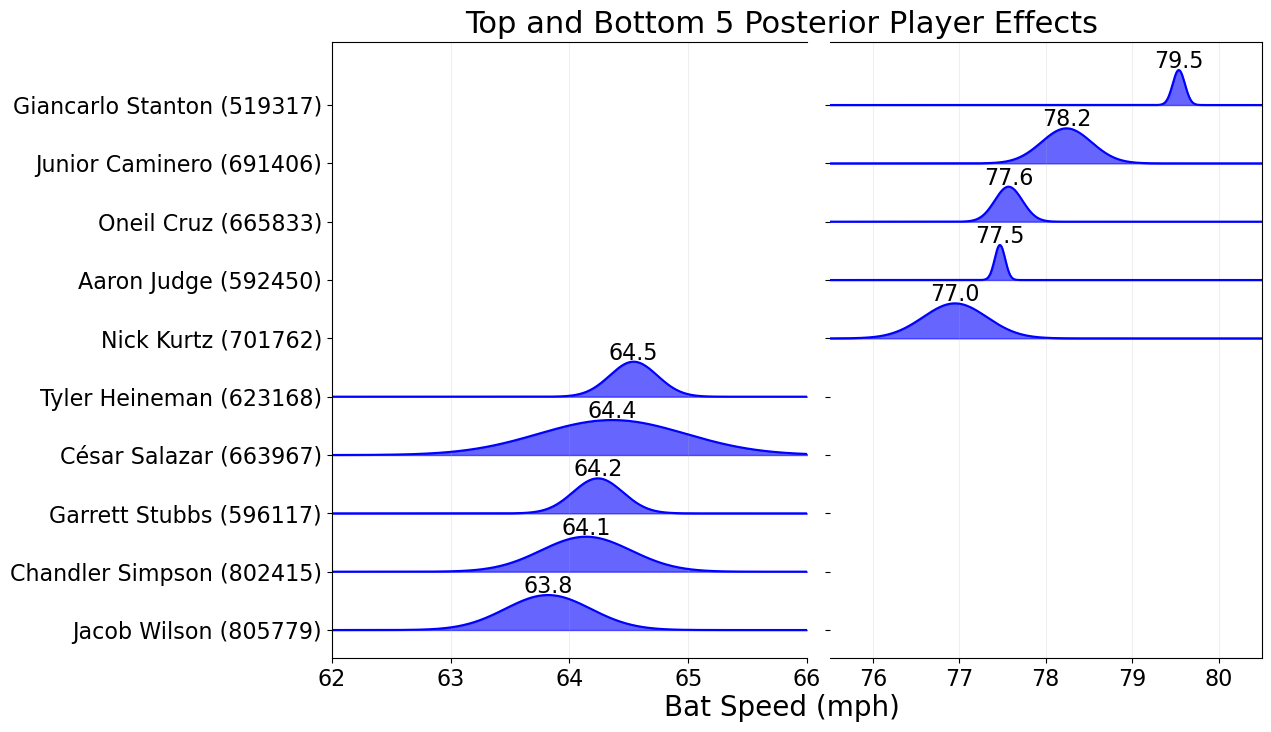

In [88]:
top_bottom = pd.concat([top, bottom]).sort_values("mean").reset_index(drop=True)
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 8), sharey=True,
    gridspec_kw={"width_ratios": [1.1, 1.0], "wspace": 0.05}
)
axes = [ax1, ax2]
ranges = [(62, 66), (75.5, 80.5)]
for ax, (xmin, xmax), group in zip(axes, ranges, [bottom, top]):
    x = np.linspace(xmin, xmax, 500)
    for i, row in top_bottom.iterrows():
        if row["player_full_id"] not in set(group["player_full_id"]):
            continue
        pdf = np.exp(-0.5 * ((x - row["mean"]) / row["sd"]) ** 2)
        pdf = pdf / pdf.max() * 0.6
        ax.fill_between(x, i, i + pdf, alpha=0.6, color="blue")
        ax.plot(x, i + pdf, color="blue")
        if xmin <= row["mean"] <= xmax:
            ax.text(row["mean"], i + 0.55, f"{row['mean']:.1f}", ha="center", va="bottom", fontsize=16)
    ax.set_xlim(xmin, xmax)
    ax.grid(axis="x", alpha=0.2)
    ax.tick_params(axis='both', labelsize=16)
ax1.set_xticks(range(62, 67))
ax1.set_yticks(range(len(top_bottom)))
ax1.set_yticklabels(top_bottom["player_full_id"])
ax1.set_ylabel("")
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(labelleft=False)
fig.supxlabel("Bat Speed (mph)", y=0.03, fontsize=20)
fig.suptitle("Top and Bottom 5 Posterior Player Effects", y=0.92, fontsize=22)
plt.show()

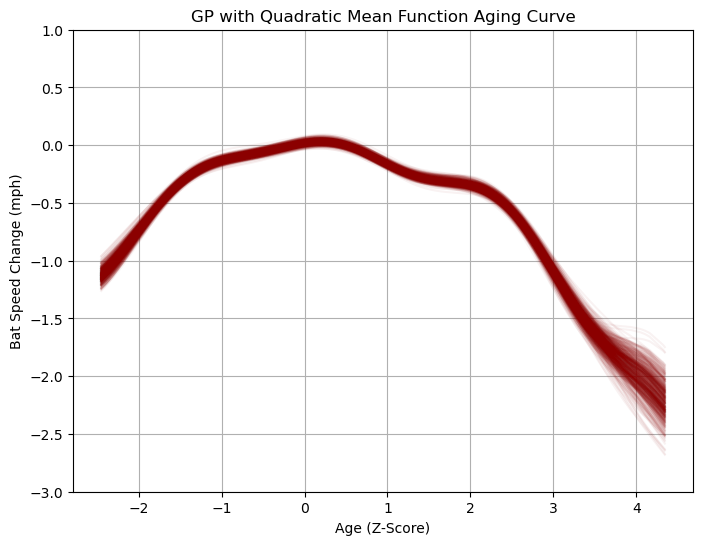

In [30]:
gp_aging_curve = plot_aging_curve(trace_gp_position, age_values, model_name="GP with Quadratic Mean Function")

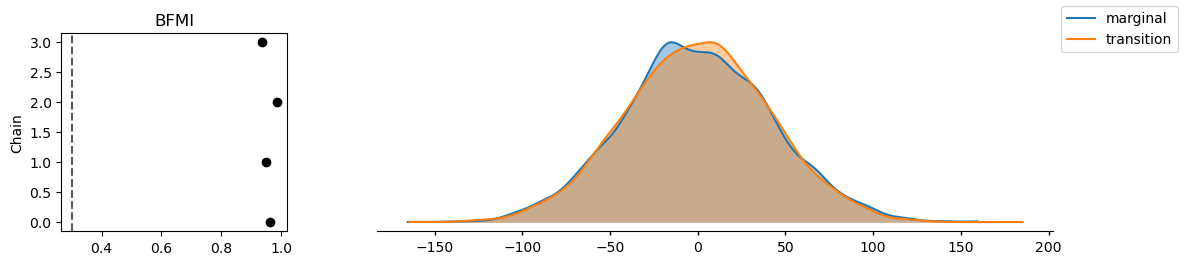

In [31]:
az.plot_energy(trace_gp_position)

In [32]:
spp = sample_posterior_pred(model_gp_position, trace_gp_position)

Sampling: [target]


Output()

Text(0.5, 1.0, 'Posterior Predictive: Bat Speed')

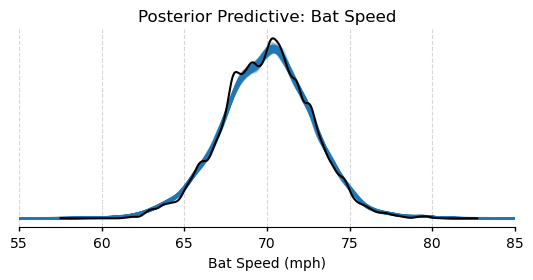

In [99]:
pc = azp.plot_ppc_dist(spp, var_names="target", num_samples=100)
ax = pc.viz["plot"]["target"].item()
ax.set_xlim(55, 85)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
ax.set_xlabel("Bat Speed (mph)")
ax.set_title("Posterior Predictive: Bat Speed")

In [34]:
posit_means = trace_gp_position.posterior['position_effect'].mean(('chain','draw'))
sorted_coord = trace_gp_position.posterior['position'].sortby(posit_means)
posit_mean_sorted = trace_gp_position.sel(position=sorted_coord)

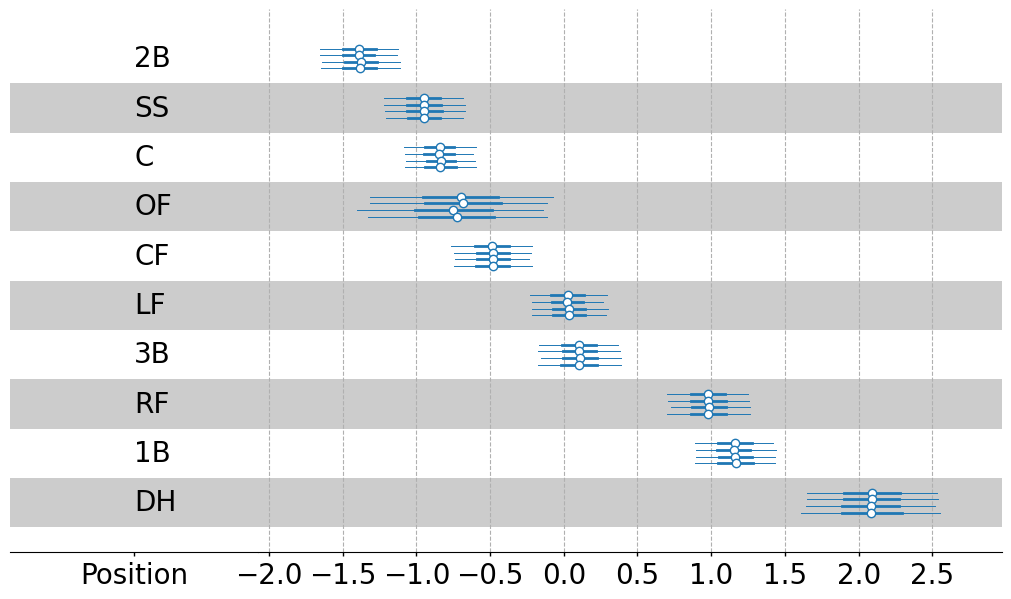

In [82]:
def rename_position(ds):
    if "position" in ds.dims:
        return ds.rename({"position": "Position"})
    return ds

posit_mean_sorted = posit_mean_sorted.map_over_datasets(rename_position)
pc = azp.plot_forest(
    posit_mean_sorted,
    var_names=['position_effect'],
    shade_label='Position',
    labels=['Position'],
    visuals={'remove_axis': True}
)
for text in plt.gcf().findobj(mtext.Text):
    text.set_fontsize(20)
ax = plt.gca()
ax.tick_params(axis='both', labelsize=20)
ax.grid(True, axis='x', linestyle='--')
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
plt.show()

In [36]:
df.columns

Index(['bam_id', 'year', 'month_name', 'time_index', 'player_full_id', 'full',
       'first', 'last', 'bats', 'birth_date', 'position', 'position_group',
       'position_hybrid', 'age', 'bips', 'ev90', 'latent_ev90_mean',
       'latent_ev90_std', 'swing_total', 'bat_speed', 'imputed_bat_speed',
       'model_bat_speed', 'is_imputed', 'is_complete', 'age_z', 'player_idx'],
      dtype='str')

In [37]:
def predict_aging_curve(
    name:str,
    trace=trace_gp_position,
    model=model_gp_position,
    mean_age=age_mean, 
    std_age=age_std
):
    age = np.linspace(18, 45, 300)
    age_z = ((age-mean_age)/std_age).reshape(-1, 1)
    with model:
        _ = gp_position.conditional(name, Xnew=age_z)
        trace_pred = pm.sample_posterior_predictive(
            trace,
            var_names=[name],
            predictions=True
            )
    f_samples = az.extract(trace_pred, group="predictions", var_names=name).values
    return age, f_samples
    

In [38]:
name = 'f_pred_age'
overall_age, f_samples = predict_aging_curve(name=name)

Sampling: []


Output()

In [39]:
def get_player_projection(
    player_full_id,
    df,
    projection_years,
    overall_age,
    f_samples,
    trace=trace_gp_position,
    start_date="2026-09-01",
    plot_start_date="2025-01-01"
):
    player_df = df[df["player_full_id"] == player_full_id].copy()
    if player_df.empty:
        raise ValueError(f"Player {player_full_id} not found in DataFrame.")

    birth_date = pd.to_datetime(player_df["birth_date"].iloc[0])
    start_plot_dt = pd.to_datetime(plot_start_date)
    start_dt = pd.to_datetime(start_date)
    end_dt = start_dt + pd.DateOffset(years=projection_years, months=1)

    min_raw_age = (start_plot_dt - birth_date).days / 365.25
    proj_start_age = (start_dt - birth_date).days / 365.25
    max_raw_age = (end_dt - birth_date).days / 365.25

    mask = (overall_age >= min_raw_age) & (overall_age <= max_raw_age)
    player_age_grid = overall_age[mask]
    f_samples = f_samples[mask, :]

    player_idx_val = player_df["player_idx"].min()
    mu_player_samples = az.extract(trace.posterior)["mu_player"].values[player_idx_val, :]
    theta_samples = mu_player_samples[None, :] + f_samples

    return player_age_grid, theta_samples, player_df, proj_start_age

In [93]:
def plot_player_projection(
    player_full_id,
    df,
    projection_years,
    overall_age,
    f_samples,
    trace=trace_gp_position,
    start_date="2026-09-01",
    plot_start_date="2025-01-01",
    ax=None
):
    age_grid, theta_samples, player_df, proj_start_age = get_player_projection(
        player_full_id, df, projection_years, overall_age, f_samples, trace, start_date, plot_start_date
    )

    mean_trajectory = theta_samples.mean(axis=1)
    hdi_50 = np.percentile(theta_samples, [25.0, 75.0], axis=1)
    hdi_95 = np.percentile(theta_samples, [2.5, 97.5], axis=1)

    standalone = ax is None
    if standalone:
        _, ax = plt.subplots(figsize=(10, 6))

    ax.fill_between(age_grid, hdi_95[0], hdi_95[1], color="blue", alpha=0.15, label="95% CI")
    ax.fill_between(age_grid, hdi_50[0], hdi_50[1], color="blue", alpha=0.30, label="50% CI")
    ax.plot(age_grid, mean_trajectory, color="navy", lw=2, label="Posterior Mean")

    obs_df = player_df[player_df["age"] >= age_grid[0]]
    ax.scatter(obs_df["age"], obs_df["model_bat_speed"], color="black", label="Observed")
    ax.axvline(x=proj_start_age, color="red", linestyle="--", alpha=0.75)

    title = f"{projection_years}-Year Bat Speed Projection: {player_full_id}" if standalone else player_full_id

    ax.set_title(title, fontsize=22)
    ax.set_xlabel("Age", fontsize=18)
    ax.set_ylabel("Bat Speed (mph)", fontsize=18)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right", fontsize=14)

    if standalone:
        ax.set_ylim(round(min(player_df["model_bat_speed"]) - 1, 0), round(max(player_df["model_bat_speed"]) + 1, 0))
        plt.tight_layout()
        plt.show()

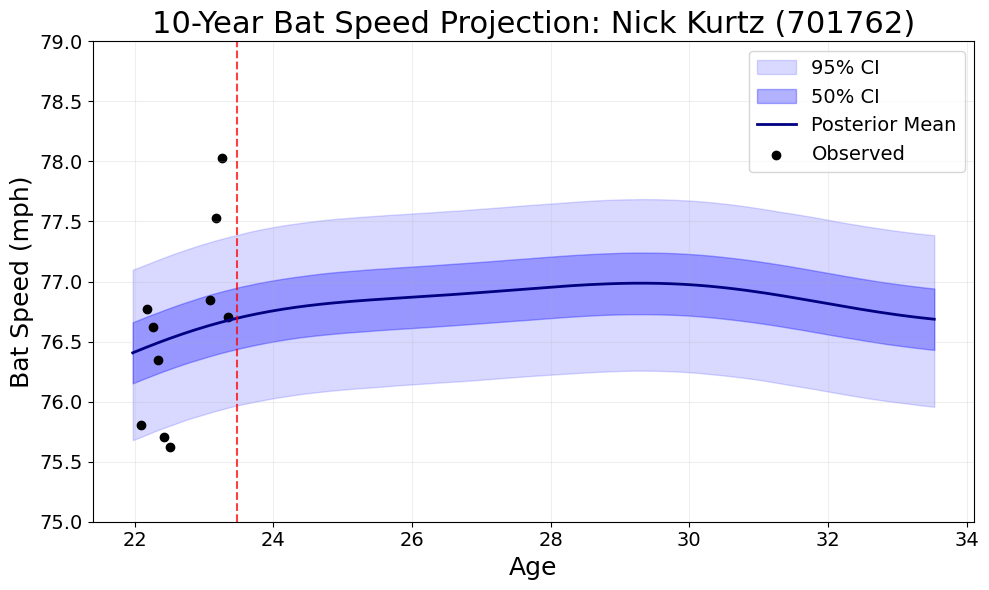

In [94]:
player_full_id='Nick Kurtz (701762)'
projection_years=10
plot_start_date = '2025-03-01'
plot_player_projection(player_full_id, df, projection_years, overall_age, f_samples, plot_start_date=plot_start_date)

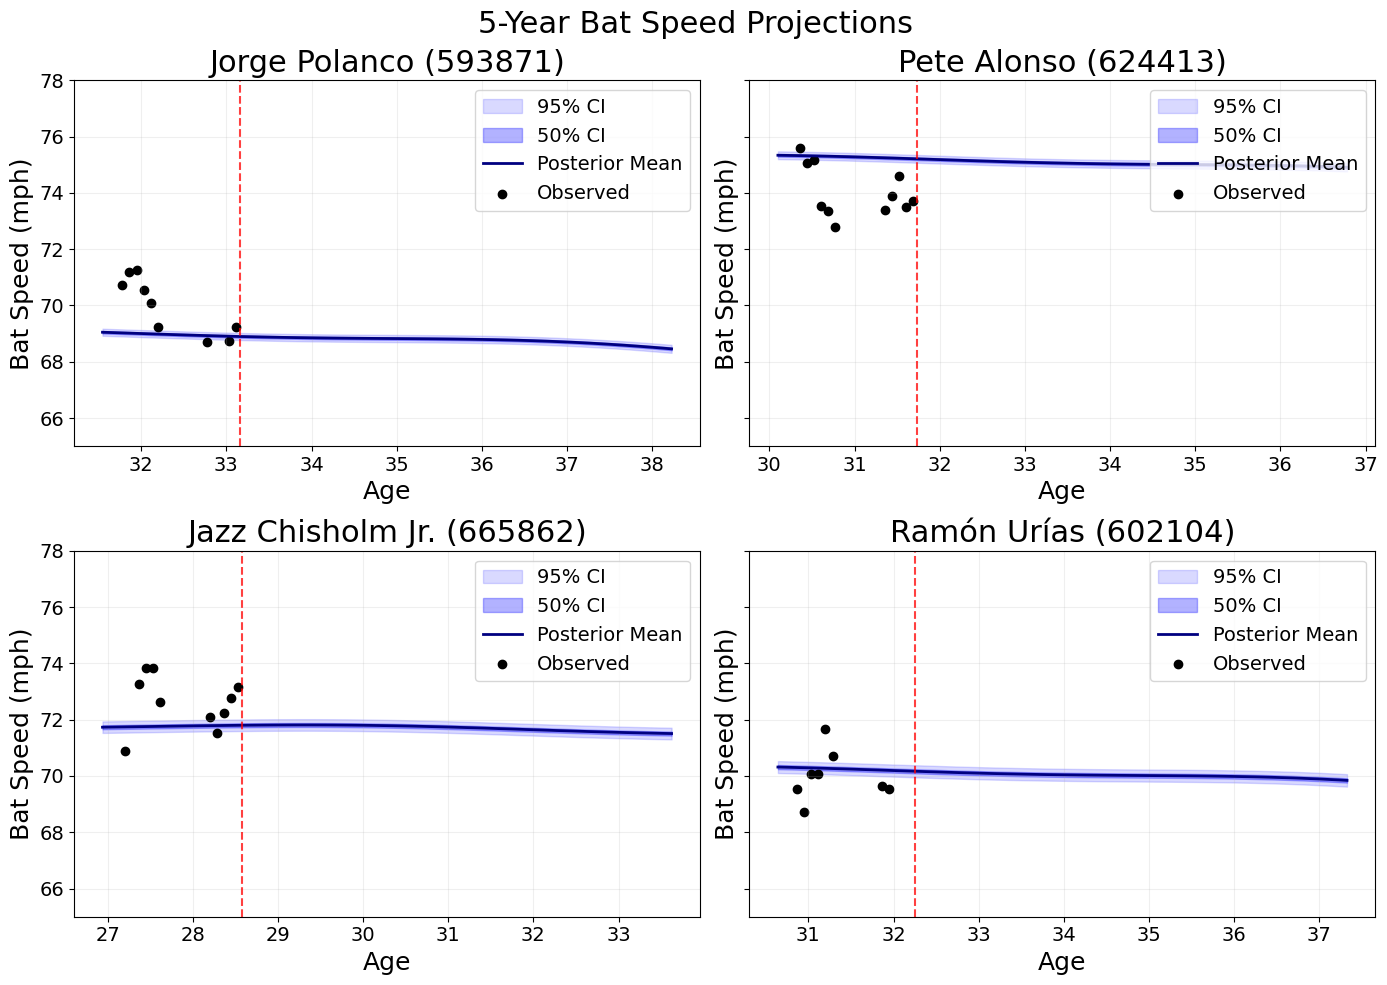

In [96]:
def plot_2x2_projections(
    player_ids,
    df,
    projection_years,
    overall_age,
    f_samples,
    trace=trace_gp_position,
    start_date="2026-09-01",
    plot_start_date="2025-01-01"
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    for player_id, ax in zip(player_ids, axes.flat):
        plot_player_projection(
            player_id,
            df,
            projection_years,
            overall_age,
            f_samples,
            trace=trace,
            start_date=start_date,
            plot_start_date=plot_start_date,
            ax=ax
        )

    sub_df = df[df["player_full_id"].isin(player_ids)]
    global_min = round(sub_df["model_bat_speed"].min() - 2, 0)
    global_max = round(sub_df["model_bat_speed"].max() + 2, 0)

    for ax in axes.flat:
        ax.set_ylim(global_min, global_max)

    fig.suptitle(f"{projection_years}-Year Bat Speed Projections", fontsize=22)
    plt.tight_layout()
    plt.show()

player_list = [
    "Jorge Polanco (593871)",
    "Pete Alonso (624413)",
    "Jazz Chisholm Jr. (665862)",
    "Ramón Urías (602104)"
]

plot_2x2_projections(
    player_ids=player_list,
    df=df,
    projection_years=5,
    overall_age=overall_age,
    f_samples=f_samples,
    plot_start_date="2025-01-01"
)

In [43]:
df.loc[df['bam_id']==650333].groupby('is_imputed')['model_bat_speed'].mean()

is_imputed
0    62.444162
1    65.528052
Name: model_bat_speed, dtype: float64

In [44]:
player_df = df.loc[df['bam_id']==650333]

player_coords = list(trace_gp_position.posterior.coords["player"].values)
player_key = player_df["player_idx"].min()
az.extract(trace_gp_position.posterior)["mu_player"].values[player_key, :].mean()

np.float64(65.39244747899045)

In [45]:
player_effects.to_csv('mu_player.csv')

In [ ]:
months = ["Mar/Apr", "May", "June", "July", "Aug", "Sept/Oct"]

def forecast(
    df,
    projection_years,
    overall_age,
    f_samples,
    trace=trace_gp_position,
    start_date="2027-03-01",
):
    column_names = [f"{m} {y}" for y in range(2027, 2027+projection_years+1) for m in months]
    year_labels = [y for y in range(2027, 2027+projection_years+1) for _ in months]
    target_elapsed = np.arange(len(column_names))/6
    df = df.copy()
    df["birth_date"] = pd.to_datetime(df["birth_date"])
    start_dt = pd.to_datetime(start_date)
    end_dt = start_dt + pd.DateOffset(years=projection_years, months=1)

    mu_players = az.extract(trace.posterior)["mu_player"].values

    rows = []
    for _, pdf in df.groupby("player_idx"):
        birth_date = pdf["birth_date"].iloc[0]

        proj_start_age = (start_dt - birth_date).days / 365.25
        max_age = (end_dt - birth_date).days / 365.25

        mask = (overall_age >= proj_start_age) & (overall_age <= max_age)
        player_age_grid = overall_age[mask]
        player_f_samples = f_samples[mask, :]

        player_idx_val = pdf["player_idx"].min()
        mu_player_samples = mu_players[player_idx_val, :]
        theta_samples = mu_player_samples[None, :] + player_f_samples
        theta_mean = theta_samples.mean(axis=1)

        elapsed = player_age_grid - proj_start_age
        yearly_vals = np.interp(target_elapsed, elapsed, theta_mean)
        yearly_ages = proj_start_age + target_elapsed

        player_full_id = pdf["player_full_id"].iloc[0]
        for label, year, val, age in zip(column_names, year_labels, yearly_vals, yearly_ages):
            rows.append({
                "player_full_id": player_full_id,
                "time": label,
                "year": year,
                "projection": val,
                "age": age,
            })

    return pd.DataFrame(rows)

In [47]:
def predict_aging_curve_forecast(
    name:str,
    trace=trace_gp_position,
    model=model_gp_position,
    mean_age=age_mean, 
    std_age=age_std
):
    age = np.linspace(18, 65, 300)
    age_z = ((age-mean_age)/std_age).reshape(-1, 1)
    with model:
        _ = gp_position.conditional(name, Xnew=age_z)
        trace_pred = pm.sample_posterior_predictive(
            trace,
            var_names=[name],
            predictions=True
            )
    f_samples = az.extract(trace_pred, group="predictions", var_names=name).values
    return age, f_samples
name = 'f_pred_age_'
forecast_age, f_samples_forecast = predict_aging_curve_forecast(name=name)

Sampling: []


Output()

In [67]:
players = df.loc[df['year']==2026].reset_index(drop=True)
resultsyr = forecast(
    players[['player_full_id','birth_date','player_idx']].drop_duplicates(),
    10,
    forecast_age,
    f_samples_forecast,
    )

In [ ]:
results10yr = resultsyr.loc[resultsyr['year']==2037]

In [75]:
results10yr.groupby(['player_full_id']).agg(
    projected_bat_speed = ('projection', 'mean'),
    projected_age = ('age', 'mean')
).reset_index().sort_values('projected_bat_speed', ascending=False).to_csv('ten_year_projections.csv')

In [77]:
results10yr.groupby(['player_full_id']).agg(
    projected_bat_speed = ('projection', 'mean'),
    projected_age = ('age', 'mean')
).reset_index().sort_values('projected_bat_speed', ascending=False)

,player_full_id,projected_bat_speed,projected_age
348,Junior Caminero (691406),77.960488,34.071697
474,Oneil Cruz (665833),76.830158,38.821869
459,Nick Kurtz (701762),76.662697,34.386550
255,Jac Caglianone (695506),76.256694,34.471424
223,Giancarlo Stanton (519317),76.250322,47.725359
...,...,...,...
261,Jacob Wilson (805779),63.499454,35.336585
535,Sandy León (506702),63.030453,48.382444
147,César Salazar (663967),62.861529,41.376283
216,Garrett Stubbs (596117),62.182786,44.179843
